# Object Detection

## 1: SSD su Penn-Fudan per il rilevamento persone
Script per addestrare rapidamente un modello SSD sul dataset Penn-Fudan per il rilevamento persone. Scarica il dataset, genera bounding box dalle maschere, crea dataloader, addestra il modello SSD300-VGG16 per 3 epoche e salva i pesi finali in 'ssd_pennfudan.pth'. Include una valutazione rapida dopo ogni epoca.

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
from PIL import Image
import torch
from torch import Tensor
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets.utils import download_and_extract_archive
from torchvision.models import VGG16_Weights
from torchvision.models.detection import ssd300_vgg16, fasterrcnn_resnet50_fpn, fasterrcnn_mobilenet_v3_large_320_fpn
from torchvision.transforms.functional import to_tensor

DOWNLOAD_PENNFUDAN: bool = True       # Metti False se hai gia' estratto la cartella in ./data

class PennFudanDataset(Dataset[Tuple[Tensor, Dict[str, Tensor]]]):
  """Dataset di riferimento (170 immagini) usato nella tutorial torchvision. Produce (immagine tensor, target dict) compatibile con i modelli di detection."""
  URL: str = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
  ZIP_NAME: str = "PennFudanPed.zip"
  FOLDER_NAME: str = "PennFudanPed"

  def __init__(self, root: str = "./data", download: bool = True) -> None:
    super().__init__()
    self.root = Path(root)
    self.dataset_root = self.root / self.FOLDER_NAME
    if download:
      self._download()
    if not self.dataset_root.exists():
      raise FileNotFoundError(
          f"PennFudanPed non trovato in {self.dataset_root}."
          "Scaricalo (download=True) oppure estrai manualmente l'archivio."
        )
    self.images = sorted((self.dataset_root / "PNGImages").glob("*.png"))
    self.masks = sorted((self.dataset_root / "PedMasks").glob("*.png"))
    if not self.images:
      raise RuntimeError("PennFudanPed sembra vuoto: controlla la struttura delle cartelle.")
  def __len__(self) -> int:
    return len(self.images)

  def __getitem__(self, idx: int) -> Tuple[Tensor, Dict[str, Tensor]]:
    img = Image.open(self.images[idx]).convert("RGB")
    mask = Image.open(self.masks[idx])
    mask_np = np.array(mask)
    obj_ids = np.unique(mask_np)
    obj_ids = obj_ids[obj_ids != 0]        # 0 --> Sfondo

    boxes_list: List[List[float]] = []
    for obj_id in obj_ids:
      ys, xs = np.where(mask_np == obj_id)
      if xs.size == 0 or ys.size == 0:
        continue

      x_min, x_max = float(xs.min()), float(xs.max())
      y_min, y_max = float(ys.min()), float(ys.max())
      boxes_list.append([x_min, y_min, x_max, y_max])

    if boxes_list:
      boxes = torch.tensor(boxes_list, dtype=torch.float32)
      labels = torch.ones((boxes.size(0),), dtype=torch.int64)  # unica classe: person
      wh = boxes[:, 2:] - boxes[:, :2]
      area = (wh[:, 0] * wh[:, 1]).clamp(min=1.0)
    else:
      boxes = torch.zeros((0, 4), dtype=torch.float32)
      labels = torch.zeros((0,), dtype=torch.int64)
      area = torch.zeros((0,), dtype=torch.float32)

    iscrowd = torch.zeros((labels.size(0),), dtype=torch.int64)

    target: Dict[str, Tensor] = {
      "boxes": boxes,
      "labels": labels,
      "image_id": torch.tensor([idx], dtype=torch.int64),
      "area": area,
      "iscrowd": iscrowd,
    }
    return to_tensor(img), target

  def _download(self) -> None:
    self.root.mkdir(parents=True, exist_ok=True)
    if self.dataset_root.exists():
      return

    download_and_extract_archive(url=self.URL, download_root=str(self.root), filename=self.ZIP_NAME,)

In [ ]:
def collate_detection(batch: List[Tuple[Tensor, Dict[str, Tensor]]]) -> Tuple[List[Tensor], List[Dict[str, Tensor]]]:
  images = [img for img, _ in batch]
  targets = [t for _, t in batch]
  return images, targets

def quick_eval(model: torch.nn.Module, loader: DataLoader, device: torch.device, score_thresh: float = 0.5) -> None:
  model.eval()
  images, _ = next(iter(loader))
  preds = model([images[0].to(device)])                       # Type: ignore[arg-type]
  keep = (preds[0]["scores"] > score_thresh).sum().item()
  print(f"[quick_eval] detections >= {score_thresh}: {keep}")

In [ ]:
def main() -> None:
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  print("Device:", device)

  # --- Dataset - Loader ---
  dataset = PennFudanDataset(root="./data", download=DOWNLOAD_PENNFUDAN)
  generator = torch.Generator().manual_seed(0)
  train_size = int(0.8 * len(dataset))
  val_size = len(dataset) - train_size
  train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=generator)

  train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, collate_fn=collate_detection)
  val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_detection)

  # --- Modello SSD ---
  model = ssd300_vgg16(weights=None, weights_backbone=VGG16_Weights.IMAGENET1K_FEATURES, num_classes=2,)
  model.to(device)

  # --- Mini Training ---
  optimizer = torch.optim.SGD(model.parameters(), lr=5e-4, momentum=0.9, weight_decay=5e-4)
  num_epochs = 3
  for epoch in range(1, num_epochs + 1):
    model.train()
    for imgs, targets in train_loader:
      imgs = [img.to(device) for img in imgs]
      targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
      '''
        boxes: tensor float32 [N, 4] con le bounding box in formato (xmin, ymin, xmax, ymax) in pixel sull'immagine originale.
        labels: tensor int64 [N] con l'id di classe di ciascun box (qui sempre 1, perche' Penn-Fudan ha solo person).
        image_id: tensor int64 [1] usato solo come identificativo interno; in questo script e' l'indice dell'immagine nel dataset.
        area: tensor float32 [N] con l'area di ogni box (serve a certe metriche, SSD non lo usa direttamente).
        iscrowd: tensor int64 [N] che segnala box crowd (COCO-style); lo teniamo tutto a zero.
      '''
      loss_dict = model(imgs, targets)  # type: ignore[arg-type]
      loss = sum(loss_dict.values())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    print(f"[epoch {epoch}] loss={loss.item():.3f}")
    quick_eval(model, val_loader, device, score_thresh=0.5)

  torch.save(model.state_dict(), "ssd_pennfudan.pth")
  print("Model saved to ssd_pennfudan.pth")

if __name__ == '__main__':
  main()

## 2: Fare un addestramento della rete Faster-RCNN sul dataset Penn-Fudan

In [ ]:
def main() -> None:
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  print("Device:", device)

  # --- Dataset - Loader ---
  dataset = PennFudanDataset(root="./data", download=DOWNLOAD_PENNFUDAN)
  generator = torch.Generator().manual_seed(0)
  train_size = int(0.8 * len(dataset))
  val_size = len(dataset) - train_size
  train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=generator)

  train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, collate_fn=collate_detection)
  val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_detection)


  #model = fasterrcnn_resnet50_fpn(weights=None, num_classes=2)
  model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=None, num_classes=2,)
  model.to(device)

  # --- Mini Training ---
  optimizer = torch.optim.SGD(model.parameters(), lr=5e-4, momentum=0.9, weight_decay=5e-4)
  num_epochs = 3
  for epoch in range(1, num_epochs + 1):
    model.train()
    for imgs, targets in train_loader:
      imgs = [img.to(device) for img in imgs]
      targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
      '''
        boxes: tensor float32 [N, 4] con le bounding box in formato (xmin, ymin, xmax, ymax) in pixel sull'immagine originale.
        labels: tensor int64 [N] con l'id di classe di ciascun box (qui sempre 1, perche' Penn-Fudan ha solo person).
        image_id: tensor int64 [1] usato solo come identificativo interno; in questo script e' l'indice dell'immagine nel dataset.
        area: tensor float32 [N] con l'area di ogni box (serve a certe metriche, SSD non lo usa direttamente).
        iscrowd: tensor int64 [N] che segnala box crowd (COCO-style); lo teniamo tutto a zero.
      '''
      loss_dict = model(imgs, targets)  # type: ignore[arg-type]
      loss = sum(loss_dict.values())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    print(f"[epoch {epoch}] loss={loss.item():.3f}")
    quick_eval(model, val_loader, device, score_thresh=0.5)

  torch.save(model.state_dict(), "mobilenet_pennfudan.pth")
  print("Model saved to mobilenet_pennfudan.pth")

if __name__ == '__main__':
  main()

Device: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 57.9MB/s]


[epoch 1] loss=0.701
[quick_eval] detections >= 0.5: 3
[epoch 2] loss=0.378
[quick_eval] detections >= 0.5: 3
[epoch 3] loss=0.306
[quick_eval] detections >= 0.5: 1
Model saved to ssd_pennfudan.pth


In [ ]:
import matplotlib.pyplot as plt
import cv2
import torch

def show_predictions(model, dataset, device, score_thresh=0.5, n=3):
  model.eval()
  for i in range(n):
    img, _ = dataset[i]
    pred = model([img.to(device)])[0]

    img_np = (img.permute(1, 2, 0).cpu().numpy() * 255).astype("uint8")
    img_np = img_np.copy()

    for box, score in zip(pred["boxes"], pred["scores"]):
      if score < score_thresh:
        continue
      x1, y1, x2, y2 = box.int().cpu().numpy()
      cv2.rectangle(img_np, (x1, y1), (x2, y2), (0, 255, 0), 2)
      cv2.putText(img_np, f"{score:.2f}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, .4, (0, 255, 0), 1)

    plt.figure(figsize=(5,5))
    plt.title(f"Prediction {i}")
    plt.imshow(img_np)
    plt.axis("off")
  plt.show()

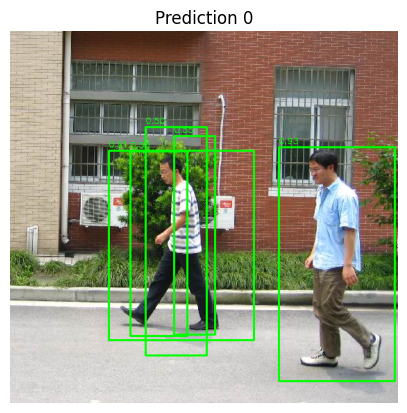

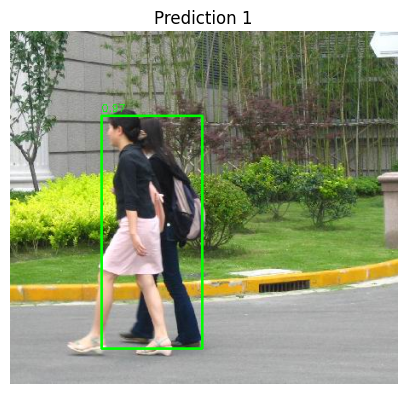

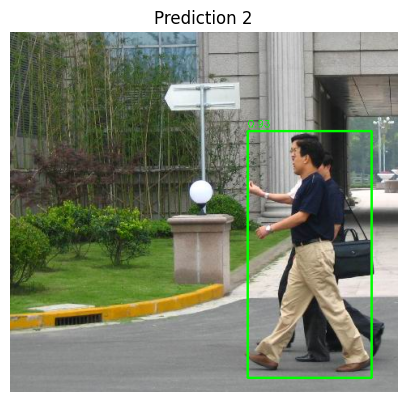

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = PennFudanDataset(root="./data", download=False)

model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=None, num_classes=2)
model.load_state_dict(torch.load("mobilenet_pennfudan.pth", map_location=device))
model.to(device)

show_predictions(model, dataset, device, score_thresh=0.5, n=3)